# Bayesian HUD Statistics

## Introduction

A HUD accumulates stats over thousands of hands you have played, but for any individual villain the sample is much smaller. There are three stages of measurement: your full hand sample, the subset of hands in which a given villain appeared, and within those hands, the subset in which a particular action was even possible. All stats are conditional in this sense — VPIP conditions on being dealt in, PFR conditions on having voluntarily entered the pot, 3B conditions on facing an open. The difference is not that some stats are conditional and others are not, but that some conditions are met more often than others.

HUDs already display frequency and sample size, implicitly inviting an informal signal-to-noise assessment. But the true SNR depends not just on sample size but on the population spread sigma. If sigma is small — meaning most players in the pool play similarly — then even a large observed deviation from the mean is likely to reflect sampling noise rather than a genuine difference in the player's true frequency. Conversely, a stat with large sigma rewards even modest samples. This interaction between sample size and population distribution is what the Bayesian framework captures precisely.

We develop a Bayesian framework for HUD statistics in three parts, in increasing order of complexity:
- Single-stat filtering: replace raw frequency with a posterior estimate that accounts for population distribution
- Archetype-based filtering: model the population as a mixture of player types, exploiting correlations across stats
- Within-hand updating: when aggregate stats are unavailable or unreliable, update archetype beliefs from sequential actions within a single hand

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from bayesian_hud.archetypes import (
    ARCHETYPE_NAMES, STAT_NAMES, get_archetype_params
)
from bayesian_hud.single_stat import (
    plot_estimation_comparison, plot_shrinkage_curves
)
from bayesian_hud.multi_stat import (
    plot_population_scatter, plot_variance_decomposition,
    plot_correlation_structure, plot_archetype_convergence,
)
from bayesian_hud.decision_tree import (
    plot_posterior_evolution, plot_path_tree, trace_path
)

## Single-Stat Bayesian Filtering

### Model

We model each player's true rate $\theta$ for a given stat as drawn from a population prior $\theta \sim \mathcal{N}(\mu, \sigma^2)$. After observing $k$ successes in $n$ opportunities the raw estimate is $\hat{\theta} = k/n$ with sampling noise $\hat{s} = \sqrt{\hat{\theta}(1-\hat{\theta})/n}$. We use Laplace smoothing $\hat{\theta} = (k + 0.5)/(n + 1)$ to avoid degenerate zero estimates at the boundary. Under the Gaussian conjugate model the posterior mean is the shrinkage estimator:
$$\theta_B = \mu + w\,(\hat{\theta} - \mu), \qquad w = \frac{\sigma^2}{\sigma^2 + \hat{s}^2}$$
This is a proper Bayesian posterior mean: a precision-weighted average of the prior mean and the observed frequency, where precision $= 1/\text{variance}$.

The weight $w$ tells us how much to trust the data versus the prior. It depends on both sample size and the stat in question. Note that $\mu$ and $\sigma$ are population-level parameters estimated from your full database across all villains. In later sections we refine these using archetype structure.

### Shrinkage weight

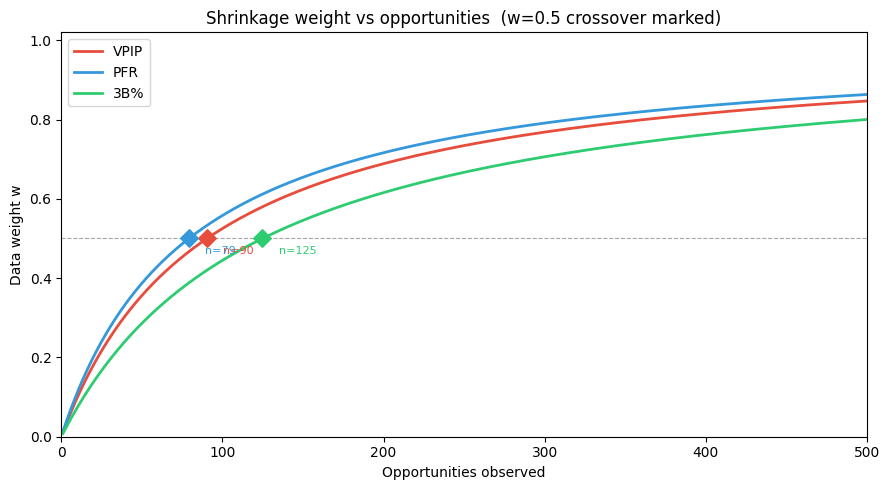

In [2]:
fig = plot_shrinkage_curves()
plt.show()

Even at 500 opportunities the weight is well below 1 for all stats, meaning the population prior always contributes. The weight varies by stat because opportunity rates and population spreads differ.

### Estimation

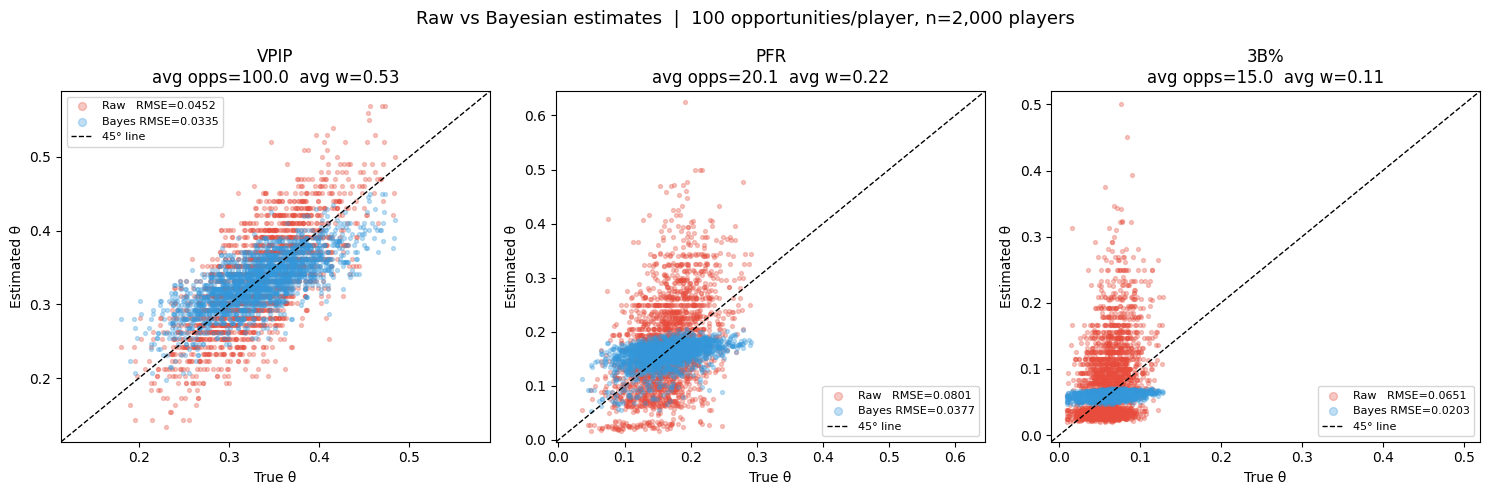

In [3]:
fig = plot_estimation_comparison(total_hands=100)
plt.show()

The Bayesian estimator reduces RMSE across all three stats at 100 hands per player. The estimate never collapses to zero thanks to Laplace smoothing and the correct precision-weighted formula.

## Archetype Definitions

The population is not homogeneous — the global distribution is multimodal, reflecting distinct player types. We model this as a mixture of $K=3$ archetypes, each with a Gaussian prior over [VPIP, PFR, 3B]. (Use 3B throughout, no percent sign.)

The three archetypes are Fish (loose-passive), TAG (tight-aggressive), LAG (loose-aggressive). The parameterisation below is illustrative — in practice these would be calibrated from your own database via EM on a Gaussian mixture model.

In [4]:
mu, sigma, pi = get_archetype_params()

header = f"{'Archetype':<8}  {'Weight':>6}  " + "  ".join(f"{s:>12}" for s in STAT_NAMES)
sep    = "-" * len(header)
print(header)
print(sep)
for k, name in enumerate(ARCHETYPE_NAMES):
    stat_cols = "  ".join(
        f"{mu[k,j]:.2f} +/- {sigma[k,j]:.2f}" for j in range(len(STAT_NAMES))
    )
    print(f"{name:<8}  {pi[k]:>6.0%}  {stat_cols}")
print(sep)
print(f"{'Total':<8}  {pi.sum():>6.0%}")

Archetype  Weight          VPIP           PFR           3B%
-----------------------------------------------------------
Fish         40%  0.45 +/- 0.06  0.10 +/- 0.04  0.03 +/- 0.02
TAG          45%  0.22 +/- 0.04  0.18 +/- 0.04  0.07 +/- 0.02
LAG          15%  0.35 +/- 0.05  0.28 +/- 0.05  0.12 +/- 0.03
-----------------------------------------------------------
Total       100%


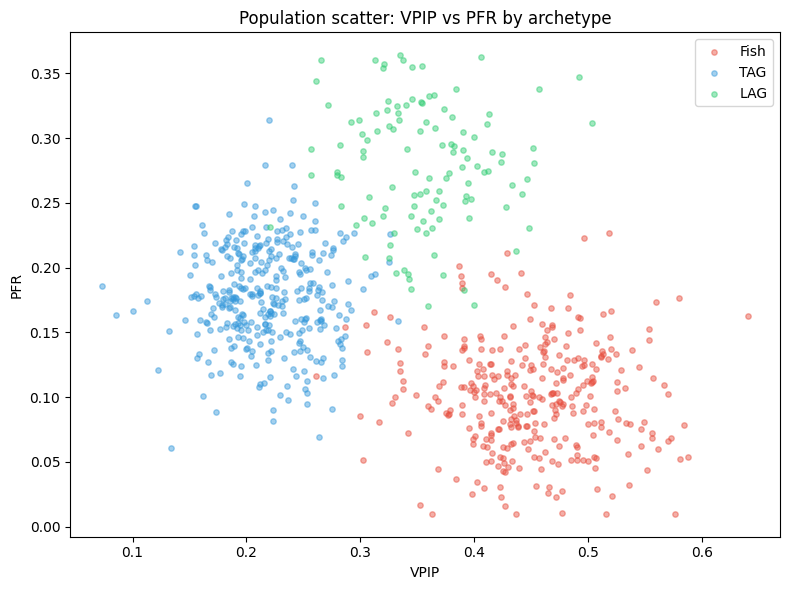

In [5]:
fig = plot_population_scatter()
plt.show()

The three archetypes form visible clusters in VPIP/PFR space, justifying the mixture model.

## Archetype-Based Multi-Stat Filtering

### Model

Rather than a single population prior, we maintain a discrete posterior over archetypes updated jointly on all three stats.

The total variance of $\hat{\theta}_j$ under archetype $k$ accounts for both the prior spread and the sampling noise:
$$v_{kj} = \sigma_{kj}^2 + \hat{s}_j^2, \qquad \hat{s}_j = \sqrt{\frac{\hat{\theta}_j(1-\hat{\theta}_j)}{n_j}}$$

The log-likelihood of the observed vector $\hat{\boldsymbol{\theta}}$ under archetype $k$ is:
$$\log p(\hat{\boldsymbol{\theta}} \mid k) = \sum_j \log \mathcal{N}\!\left(\hat{\theta}_j;\; \mu_{kj},\; v_{kj}\right)$$

and the posterior is:
$$P(k \mid \hat{\boldsymbol{\theta}}) \propto \pi_k \cdot p(\hat{\boldsymbol{\theta}} \mid k)$$

The final estimate for stat $j$ is the archetype-posterior-weighted shrinkage:
$$\hat{\theta}^{\text{arch}}_j = \sum_k P(k \mid \hat{\boldsymbol{\theta}})\cdot \hat{\theta}^B_{kj}$$

where $\hat{\theta}^B_{kj}$ is the per-archetype shrinkage estimate.

### Intra- vs inter-archetype variation

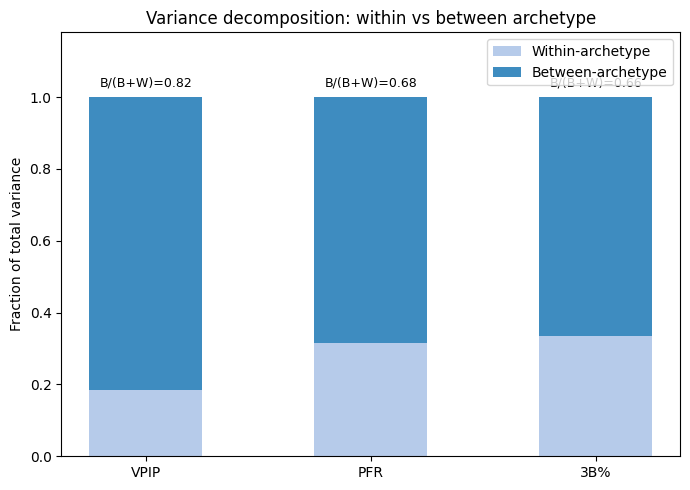

In [6]:
fig = plot_variance_decomposition()
plt.show()

By the law of total variance, $\operatorname{Var}(\theta_j) = \sum_k \pi_k (\mu_{kj} - \bar{\mu}_j)^2 + \sum_k \pi_k \sigma_{kj}^2$, decomposing into between-archetype and within-archetype components. A high between/(between + within) ratio means a single observation of that stat shifts the archetype posterior substantially.

VPIP has the highest between-archetype fraction, making it the most discriminating preflop stat. 3B has a lower ratio, partly because it is observed so rarely. Crucially, VPIP alone cannot separate TAG from LAG — both have moderate-to-high values — which motivates the multi-stat approach and foreshadows the TAG/LAG identification problem we return to later.

### Covariance structure

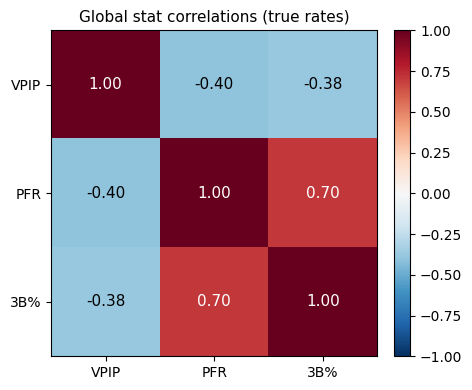

In [7]:
fig = plot_correlation_structure()
plt.show()

Globally, VPIP, PFR, and 3B are strongly correlated because different archetypes have different joint profiles — Fish clusters at high VPIP with low PFR and low 3B; LAG clusters at high values across all three; TAG sits between them with moderate VPIP and high aggression relative to VPIP.

Multi-stat updating exploits this structure: observing high VPIP shifts the posterior toward Fish or LAG, which immediately adjusts our expectation for PFR and 3B even before observing those stats directly. The Bayesian model uses this joint covariance implicitly through the archetype likelihood.

### Archetype identification and estimation improvement

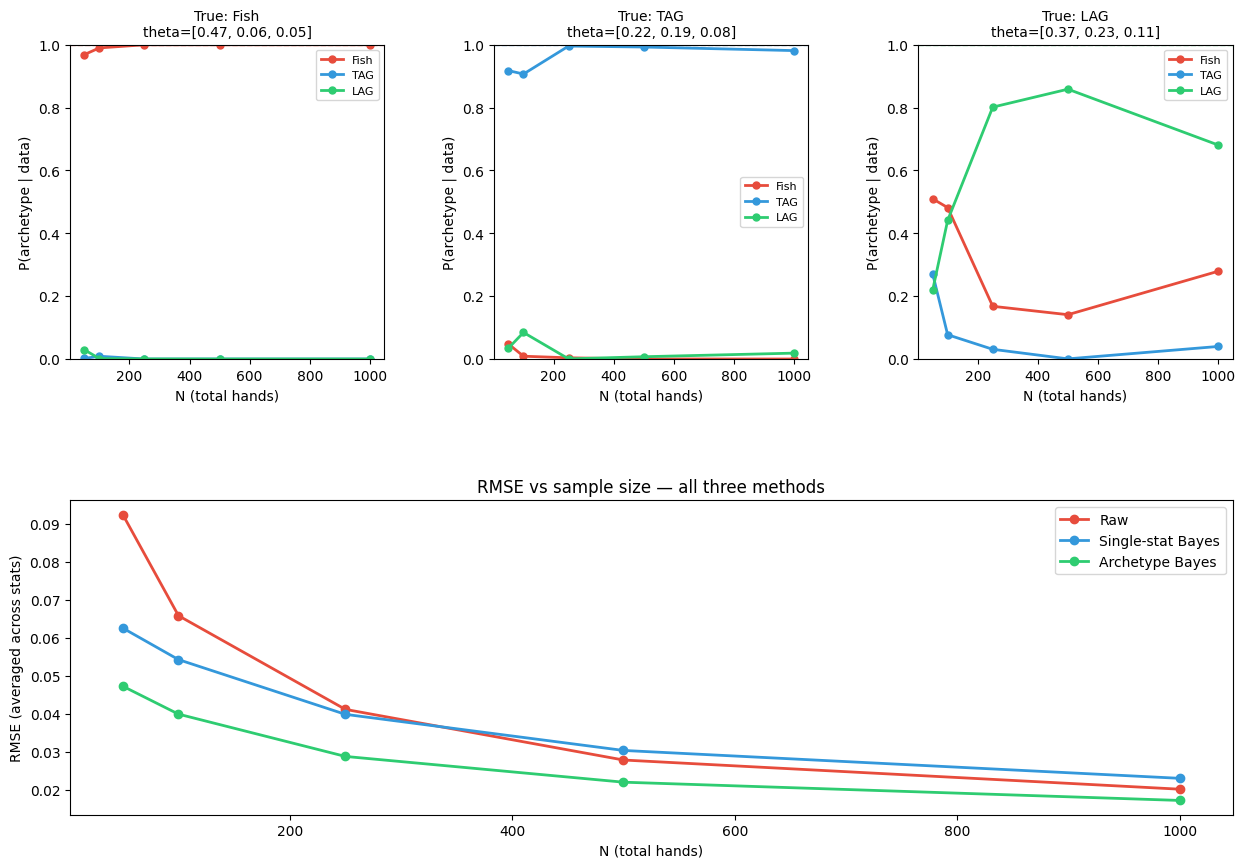

In [8]:
fig = plot_archetype_convergence()
plt.show()

Row 1 shows the archetype posterior for one representative player from each archetype as N grows. Fish is identified quickly: high VPIP with low PFR and 3B provides an unambiguous signal and the posterior converges to the correct archetype at moderate sample sizes. LAG takes longer because it overlaps with TAG in VPIP/PFR space and has lower mixture weight, making it harder to distinguish from the prior.

Row 2 shows RMSE averaged across all stats and all players for each of the three methods as N grows. Archetype Bayes dominates at all sample sizes, with the largest absolute gains at small N where the prior matters most. The gap narrows as N increases and the data overwhelm the prior, but archetype Bayes never loses to single-stat Bayes because the archetype layer adds information rather than replacing it.

The ambiguous region between TAG and LAG in preflop stat space is a genuine limitation — preflop stats alone may be insufficient to separate them. Two players with VPIP around 0.28 and PFR around 0.22 could plausibly belong to either archetype, and the posterior correctly reflects this uncertainty. This motivates the within-hand updating approach in the next section, which draws on action sequences rather than aggregate frequencies.

## Within-Hand Updating

### Motivation

Zone poker tables shuffle players after every hand, so no hand history accumulates even within a session. More generally, use case 3 activates whenever aggregate stats are too thin — a villain seen in 10 hands provides essentially no VPIP/PFR signal. Within-hand sequential actions can substitute: each observed action (call, fold, raise) is a draw from the archetype's action distribution, and Bayesian updating proceeds action by action.

Large population samples for calibrating action probabilities are more attainable than it might seem — hand history databases are commercially available. The parameter space is large (action probabilities at each node per archetype) but the population frequency of each node can be estimated from aggregate data. Treat the parameterisation here as illustrative.

### Decision tree

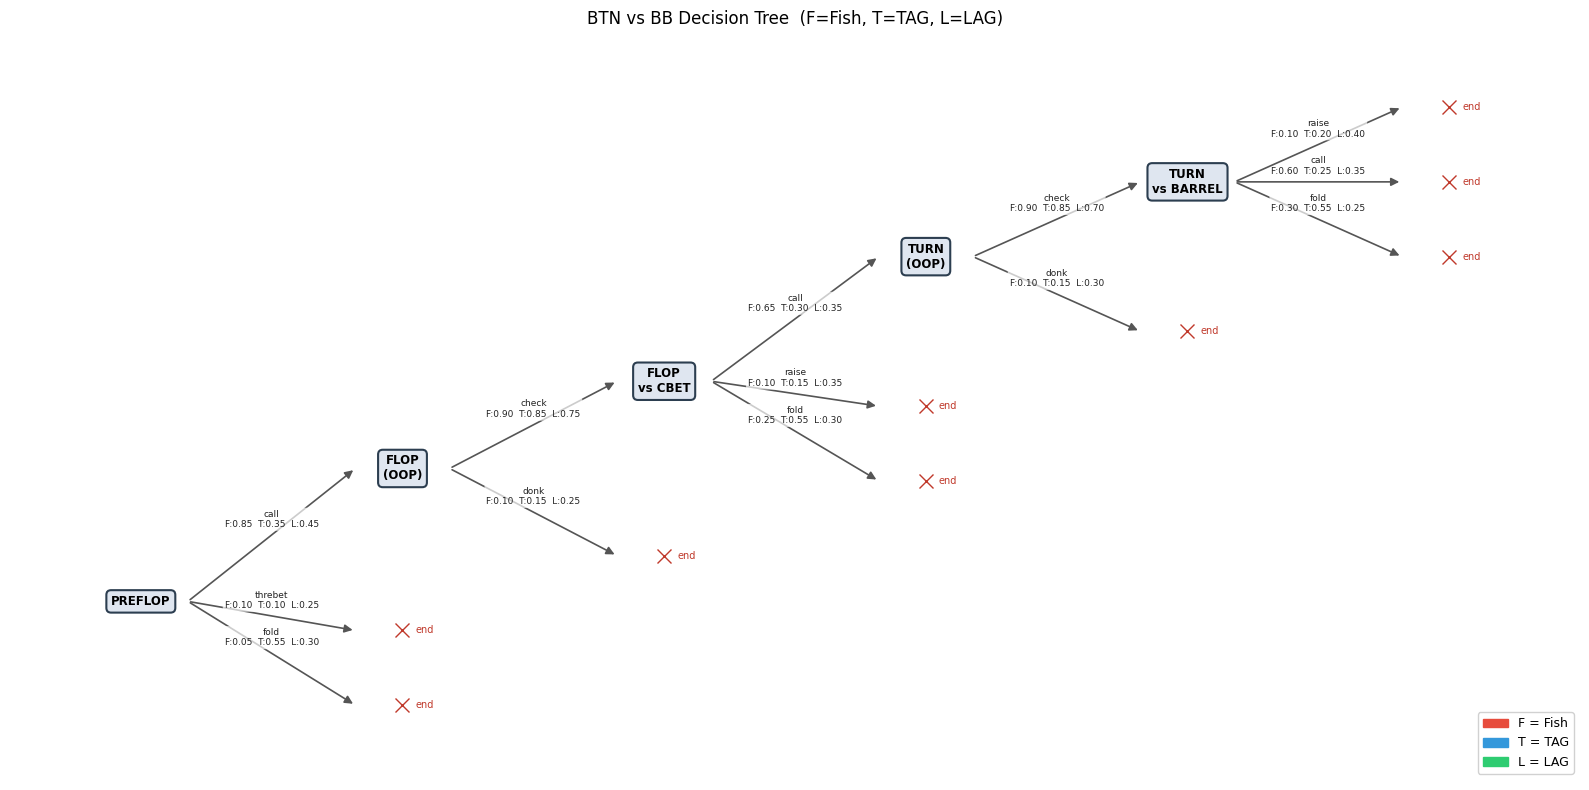

In [9]:
fig = plot_path_tree()
plt.show()

The tree shows the BTN-vs-BB decision nodes used in the within-hand updater, with branches for each possible action at each node.

### Posterior evolution

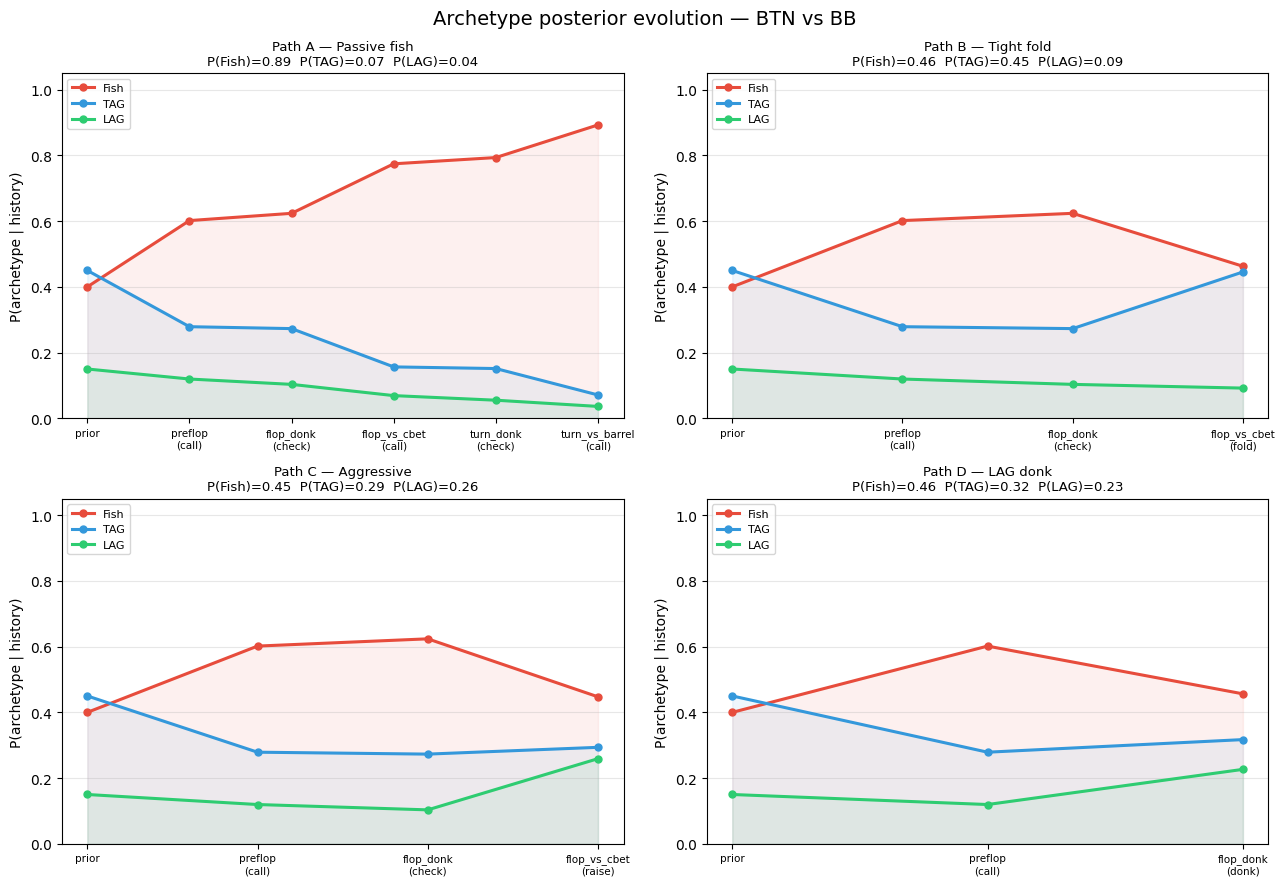

In [10]:
fig = plot_posterior_evolution()
plt.show()

Each panel traces the archetype posterior along a specific action sequence. Path A (passive call-down) quickly converges to Fish: calling preflop, checking, calling a c-bet, and calling again is highly characteristic of the loose-passive archetype. Path C (flop raise) shifts toward LAG: raising the flop after calling preflop is a more aggressive line that Fish rarely takes.

Note the connection to the TAG/LAG identification problem from the previous section: Path B (tight fold) leaves TAG and LAG largely unresolved, consistent with our finding that preflop behaviour alone is insufficient to separate them. A villain who folds to a c-bet could be either a disciplined TAG or a LAG who picked up no equity — the within-hand updater faithfully retains this uncertainty rather than forcing a label.

### Custom trace

In [11]:
paths = {
    "Path 1: call \u2192 check \u2192 vs-cbet call \u2192 check \u2192 vs-barrel raise": [
        ("preflop",        "call"),
        ("flop_donk",      "check"),
        ("flop_vs_cbet",   "call"),
        ("turn_donk",      "check"),
        ("turn_vs_barrel", "raise"),
    ],
    "Path 2: preflop 3-bet": [
        ("preflop", "threbet"),
    ],
}

for path_name, seq in paths.items():
    history, final = trace_path(seq)
    print(f"\n{'='*70}")
    print(f"  {path_name}")
    print(f"{'='*70}")
    header = (
        f"  {'Step':<4}  {'Node':<18}  {'Action':<12}  "
        + "  ".join(f"P({n})" for n in ARCHETYPE_NAMES)
    )
    print(header)
    print(f"  {'-'*68}")
    row_labels = [("prior", "-")] + list(seq)
    for i, (node, action) in enumerate(row_labels):
        probs = "  ".join(f"{history[i][k]:>7.3f}" for k in range(len(ARCHETYPE_NAMES)))
        print(f"  {i:<4}  {node:<18}  {action:<12}  {probs}")


  Path 1: call → check → vs-cbet call → check → vs-barrel raise
  Step  Node                Action        P(Fish)  P(TAG)  P(LAG)
  --------------------------------------------------------------------
  0     prior               -               0.400    0.450    0.150
  1     preflop             call            0.602    0.279    0.119
  2     flop_donk           check           0.624    0.273    0.103
  3     flop_vs_cbet        call            0.775    0.156    0.069
  4     turn_donk           check           0.794    0.151    0.055
  5     turn_vs_barrel      raise           0.603    0.230    0.167

  Path 2: preflop 3-bet
  Step  Node                Action        P(Fish)  P(TAG)  P(LAG)
  --------------------------------------------------------------------
  0     prior               -               0.400    0.450    0.150
  1     preflop             threbet         0.327    0.367    0.306


## Summary and Extensions

### What the framework achieves

Bayesian shrinkage consistently outperforms raw frequencies in the small-sample regime — exactly where HUD data is least reliable and most consequential. The archetype layer pools information across stats, enabling archetype identification even when each individual stat is too noisy to be conclusive on its own. The within-hand updater extends this to anonymous opponents where no history exists at all.

### Limitations and extensions

- Independence across stats within archetypes is assumed but easily relaxed: a full covariance matrix per archetype can be calibrated from population data, capturing e.g. the correlation between PFR and 3B within the TAG archetype.
- Archetype parameters (means, variances, mixture weights, action probabilities) are all estimable from large HUD databases via standard mixture model methods.
- The natural downstream application is EV-weighted decision making: once we have a posterior over archetypes, we can compute the expected value of different actions conditional on villain type. For example, if the posterior assigns high probability to Fish by the river, the EV of a large value bet increases due to passive calling tendencies. The archetype posterior becomes an input to a decision model, not just a descriptive statistic.